In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('../data/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

## Data Preparation

Scaling is essential before applying K-Means because the algorithm relies on distance-based calculations. 
If features are on different scales, variables with larger magnitudes (e.g., annual spend) will dominate the clustering process.

StandardScaler ensures all features are normalized, allowing each variable to contribute equally to cluster formation.

In [4]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


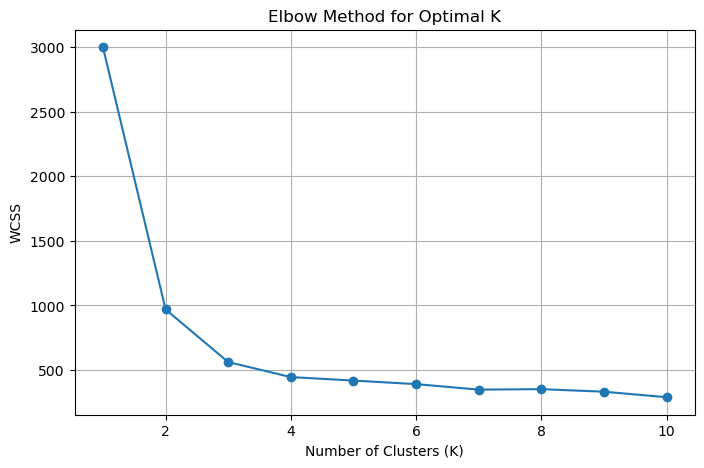

In [5]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

## Choosing K — Elbow Method

The elbow point is observed at K = 3, where the rate of decrease in WCSS sharply slows down.

From K = 1 to K = 3, there is a significant reduction in WCSS, indicating meaningful cluster formation. 
However, beyond K = 3, the decrease becomes gradual, suggesting diminishing returns from adding more clusters.

Therefore, K = 3 is chosen as the optimal number of clusters as it balances model simplicity and performance.

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['cluster'] = clusters

In [7]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


## Cluster Interpretation

Cluster 0 represents young customers who visit frequently but spend relatively less per transaction. 
These customers have small basket sizes and recent activity, indicating engagement but low monetary value.

Cluster 1 represents high-value customers who spend significantly more per purchase but visit infrequently. 
They tend to purchase a wide variety of products in large quantities, suggesting bulk or planned buying behavior.

Cluster 2 represents regular customers with moderate spending and visit frequency. 
They maintain a balance between engagement and spending, making them stable and consistent contributors to revenue.

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [9]:
pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

In [10]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## PCA Interpretation

PC1 represents overall customer value and purchasing intensity. 
It is strongly influenced by features such as annual spend, basket size, and number of categories purchased, indicating customers who contribute higher revenue through larger and more diverse purchases. 
The negative relationship with visit frequency suggests that high-value customers tend to visit less often but make larger transactions.

PC2 primarily captures customer recency, as it is dominated by days_since_last_visit. 
This indicates how recently a customer has interacted with the business, distinguishing between active and inactive customers.

Together, PC1 and PC2 effectively summarize customer value and engagement patterns, enabling meaningful visualization of clusters.

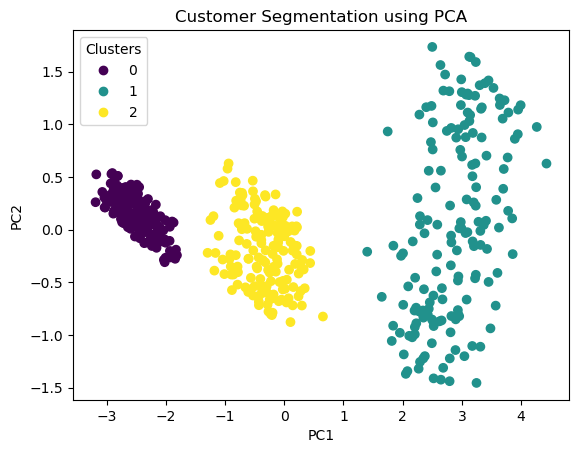

In [11]:
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['cluster'], cmap='viridis')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation using PCA')

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

## Cluster Visualization

The scatter plot shows three clearly separated clusters in the PCA-reduced space, indicating that the K-Means algorithm has effectively segmented the customers.

The separation along PC1 highlights differences in customer value and purchasing behavior, while PC2 reflects variations in recency of visits.

The minimal overlap between clusters confirms that K = 3 is an appropriate choice and that the identified segments are distinct and meaningful for business analysis.